# tabUM v1.1: a guided tour of the released model

tabUM is a small (14.31M parameter) tabular foundation model. You give it your
training rows, it predicts your test rows in a single forward pass. There is no
per-dataset training in the classic sense: the "learning" happened once, during
pretraining on millions of synthetic tasks, and at prediction time the model
*reads* your dataset the way a language model reads a prompt. This is called
in-context learning (ICL).

Practical consequences of that design:

- `fit(X, y)` is instant: it just stores your data.
- `predict(X_test)` runs one forward pass in which every test row attends to
  every training row.
- Missing values are first-class: leave `NaN` in, the model treats missingness
  itself as signal (no imputation, ever).
- Up to 100 classes and 2,000 features; context sizes validated to 64k rows.

This notebook walks the full API: loading from safetensors, prediction,
test-time ensembling, `finetune()`, and `explain()`.

## 1. Load the released weights

The release directory holds `model.safetensors` (the weights, 57 MB) and
`config.json` (the architecture). This is exactly the format published on
HuggingFace, so the same call works on a downloaded snapshot.

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tabum.model import TabUM
from tabum.inference import TabUMClassifier, TabUMRegressor
from tabum.inference.encoding import to_numeric

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

from huggingface_hub import snapshot_download
model = TabUM.from_pretrained(snapshot_download("helmo/tabum-v1.1"), device=device)
print(f"tabUM v1.1 loaded: {sum(p.numel() for p in model.parameters())/1e6:.2f}M params on {device}")
# shared plot style: recessive axes, ink for text, data carries the color
BLUE, AQUA, INK, MUTED = "#2a78d6", "#1baf7a", "#0b0b0b", "#52514e"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.titlecolor": INK, "figure.dpi": 110})

/Users/hm/Documents/prompts/tabum-v1.1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 4 files: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 18766.46it/s]

tabUM v1.1 loaded: 14.31M params on mps


## 2. Classification quickstart: customer churn

Any DataFrame works after `to_numeric`, which factorizes strings/categoricals
to integer codes and converts datetimes (drop free-text and ID columns, they
carry no signal). The model receives raw values plus NaNs.

In [4]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

X, y = fetch_openml(data_id=40701, return_X_y=True, as_frame=True)
Xn = to_numeric(X).astype(np.float32)
yn = np.asarray(y.factorize()[0])
Xtr, Xte, ytr, yte = train_test_split(Xn, yn, train_size=2000, test_size=1000,
                                      random_state=0, stratify=yn)

clf = TabUMClassifier(model=model, n_ensemble=8).fit(Xtr, ytr)   # fit = store data, instant
print(f"churn accuracy: {(clf.predict(Xte) == yte).mean():.3f}")
print(f"calibrated probabilities, first 3 rows:\n{np.round(clf.predict_proba(Xte)[:3], 3)}")

churn accuracy: 0.908
calibrated probabilities, first 3 rows:
[[0.974 0.026]
 [0.482 0.518]
 [0.964 0.036]]


## 3. Regression: distributions, not just points

The regression head predicts a full distribution over the target for every
test row (a histogram over 100 bins). `predict` returns its mean;
`predict_quantile` reads any quantile from the same forward pass, so
uncertainty bands are free.

cpu_act R2: 0.946
80% interval coverage: 87.9%


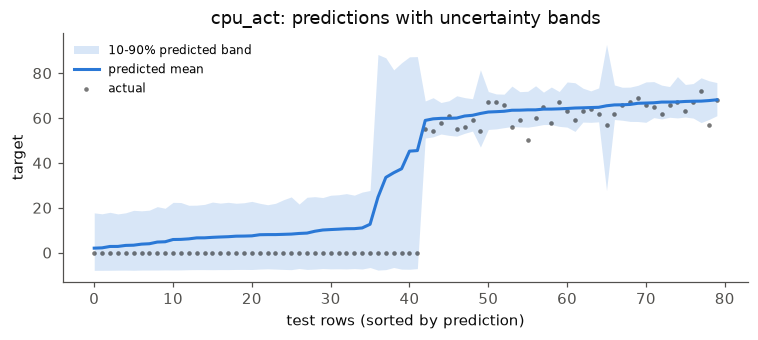

In [5]:
from sklearn.metrics import r2_score

Xr, yr = fetch_openml(data_id=227, return_X_y=True, as_frame=True)  # cpu_act
Xrn = to_numeric(Xr).astype(np.float32)
yrn = yr.to_numpy(dtype=np.float32)
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(Xrn, yrn, train_size=2000,
                                              test_size=1000, random_state=0)

reg = TabUMRegressor(model=model, n_ensemble=8).fit(Xtr_r, ytr_r)
pred = reg.predict(Xte_r)
lo, hi = reg.predict_quantile(Xte_r, 0.1), reg.predict_quantile(Xte_r, 0.9)
print(f"cpu_act R2: {r2_score(yte_r, pred):.3f}")
print(f"80% interval coverage: {((yte_r >= lo) & (yte_r <= hi)).mean():.1%}")

# order 80 test rows by prediction and show the band around them
o = np.argsort(pred)[:80]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.fill_between(range(len(o)), lo[o], hi[o], color=BLUE, alpha=0.18,
                linewidth=0, label="10-90% predicted band")
ax.plot(range(len(o)), pred[o], color=BLUE, linewidth=2, label="predicted mean")
ax.scatter(range(len(o)), yte_r[o], s=9, color=INK, alpha=0.55, linewidth=0,
           label="actual")
ax.set(title="cpu_act: predictions with uncertainty bands",
       xlabel="test rows (sorted by prediction)", ylabel="target")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()

## 4. Test-time ensembling: same model, several viewpoints

tabUM should not care about column order or which integer denotes which class,
but no network is perfectly invariant to arbitrary choices like these. Each
prediction is therefore signal plus a little "arbitrary-choice noise".

`n_ensemble=k` runs the same weights on k shuffled views of your data (column
order and class indices permuted differently each time) and averages the
probabilities. The signal agrees across views, the noise does not, so averaging
cancels it. Cost: k forward passes. Gains are largest for many-class problems,
where class-index noise is largest. Watch it on letter (26 classes):

1 pass: 0.604  ->  16 views: 0.802


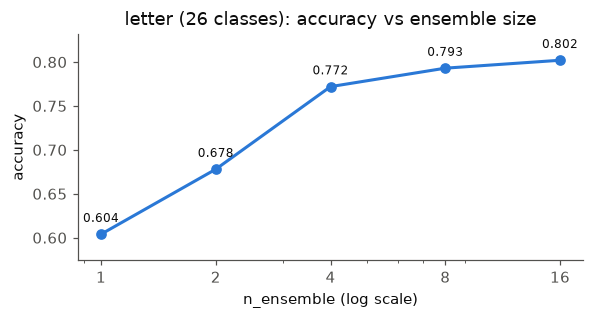

In [6]:
Xl, yl = fetch_openml(data_id=6, return_X_y=True, as_frame=True)  # letter
Xln = to_numeric(Xl).astype(np.float32)
yln = np.asarray(yl.factorize()[0])
Xtr_l, Xte_l, ytr_l, yte_l = train_test_split(Xln, yln, train_size=2000,
                                              test_size=1000, random_state=0,
                                              stratify=yln)
ks = [1, 2, 4, 8, 16]
accs = []
for k in ks:
    c = TabUMClassifier(model=model, n_ensemble=k).fit(Xtr_l, ytr_l)
    accs.append((c.predict(Xte_l) == yte_l).mean())

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.plot(ks, accs, color=BLUE, linewidth=2, marker="o", markersize=6)
for k, a in zip(ks, accs):
    ax.annotate(f"{a:.3f}", (k, a), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color=INK)
ax.set(title="letter (26 classes): accuracy vs ensemble size",
       xlabel="n_ensemble (log scale)", ylabel="accuracy", xscale="log")
ax.set_xticks(ks, [str(k) for k in ks])
ax.margins(y=0.15)
plt.tight_layout()
print(f"1 pass: {accs[0]:.3f}  ->  16 views: {accs[-1]:.3f}")

`n_ensemble=8` is the recommended default: most of the gain, still fast.
Reproducible too, the view permutations are seeded.

## 5. finetune(): optional per-dataset adaptation

`fit()` never changes the weights. `finetune(X, y)` does, safely:

1. It deep-copies the model, your loaded base model is never modified.
2. It repeatedly splits *your training rows* into a pseudo-context and
   pseudo-targets and trains the copy to predict one from the other, the same
   objective as pretraining, just on your data distribution.
3. A held-out slice of your training rows (never used as targets) is monitored
   for early stopping, so small datasets do not overfit.

Takes about 10-20 seconds on a GPU. On the TabArena benchmark it helped on 28
of 51 datasets and hurt on 2, with the biggest gains on regression.

In [7]:
ft = TabUMClassifier(model=model, n_ensemble=8).finetune(Xtr, ytr)
print(f"churn zero-shot:  {(clf.predict(Xte) == yte).mean():.3f}")
print(f"churn finetuned:  {(ft.predict(Xte) == yte).mean():.3f}")

churn zero-shot:  0.908
churn finetuned:  0.922


## 6. explain(): why did it predict that?

Two explanation methods, both validated against synthetic tasks where the truly
informative features are known by construction (see
`scripts/validate_explain.py`; ranking AUC 0.99 for regression, 0.94 median for
classification):

- **feature_importances**: for each column, drop it from the entire world
  (training context and test rows) and measure how much the predictions
  degrade. Because `fit()` is storage-only this "leave one covariate out"
  costs one forward pass per feature instead of one retraining per feature.
  Caveat: correlated features split credit, as in every perturbation method.
- **neighbors** (classification): the classification head literally predicts by
  attending over training rows and averaging their labels, so the attention
  weights are the actual votes, not a post-hoc reconstruction.

Titanic is a good demo: mixed types, missing values, and everyone knows the
ground truth.

top features: sex, pclass, age


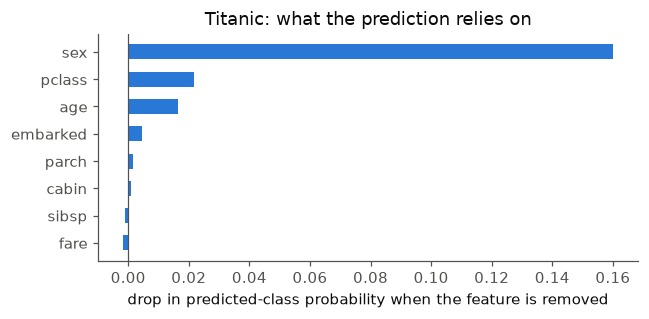

In [8]:
Xt, yt = fetch_openml(data_id=40945, return_X_y=True, as_frame=True)
Xt = Xt.drop(columns=["boat", "body", "home.dest", "name", "ticket"])  # leakage/ID columns
cols = list(Xt.columns)
Xtn = to_numeric(Xt).astype(np.float32)
ytn = np.asarray(yt.astype(int))
Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(Xtn, ytn, train_size=0.7,
                                              random_state=0, stratify=ytn)

clf_t = TabUMClassifier(model=model).fit(Xtr_t, ytr_t)
out = clf_t.explain(Xte_t)

imp = out["feature_importances"]
o = np.argsort(imp)
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh([cols[j] for j in o], imp[o], color=BLUE, height=0.55)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set(title="Titanic: what the prediction relies on",
       xlabel="drop in predicted-class probability when the feature is removed")
plt.tight_layout()
print("top features:", ", ".join(cols[j] for j in np.argsort(imp)[::-1][:3]))

The model rediscovers the historical record with no domain knowledge: `sex`
dominates, then `pclass` and `age` ("women and children first, first class
first"), and the ID-like `cabin` and noisy `fare` contribute nothing.

For a single prediction, the neighbor view shows the strongest training-row
votes. Read it carefully: with hundreds of context rows the attention is
spread thin, so the top rows shown are the largest individual votes, while
the predicted probability is the tally of *all* of them.

prediction: died (p=0.84); top-5 votes cover 4.4% of total attention


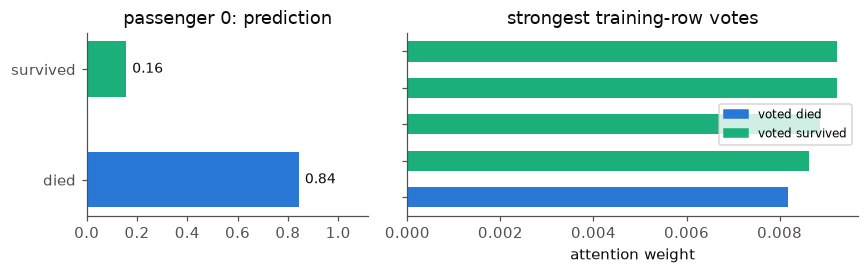

In [9]:
i = 0
p = clf_t.predict_proba(Xte_t[i:i+1])[0]
w, lbl = out["neighbor_weight"][i], out["neighbor_label"][i]

fig, axes = plt.subplots(1, 2, figsize=(8, 2.6), width_ratios=[1, 1.6])
axes[0].barh(["died", "survived"], [p[0], p[1]], color=[BLUE, AQUA], height=0.5)
for yy, v in enumerate(p):
    axes[0].annotate(f"{v:.2f}", (v, yy), textcoords="offset points",
                     xytext=(4, 0), va="center", fontsize=9, color=INK)
axes[0].set(title=f"passenger {i}: prediction", xlim=(0, 1.12))

colors = [AQUA if l == 1 else BLUE for l in lbl]
axes[1].barh(range(len(w) - 1, -1, -1), w, color=colors, height=0.55)
axes[1].set(title="strongest training-row votes", xlabel="attention weight",
            yticks=range(len(w)), yticklabels=[])
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE),
           plt.Rectangle((0, 0), 1, 1, color=AQUA)]
axes[1].legend(handles, ["voted died", "voted survived"], frameon=True, fontsize=8)
plt.tight_layout()
print(f"prediction: {'survived' if p.argmax() == 1 else 'died'} (p={p.max():.2f}); "
      f"top-{len(w)} votes cover {w.sum():.1%} of total attention")

## 7. Your own data

Everything above works on any numpy array or DataFrame. Rules of thumb:

- strings and categories: run the DataFrame through `to_numeric` first
- free-text and ID columns: drop them, near-unique codes are pure noise
- missing values: leave them as NaN, imputation destroys signal
- a few hundred training rows or more works best; context is validated to 64k
- defaults to reach for: `n_ensemble=8`, then `finetune()` if you want more

In [10]:
rng = np.random.default_rng(0)
X_own = rng.standard_normal((500, 8)).astype(np.float32)
X_own[rng.random(X_own.shape) < 0.1] = np.nan          # 10% missing, fed raw
y_own = (np.nansum(X_own[:, :3], 1) > 0).astype(int)

own = TabUMClassifier(model=model, n_ensemble=8).fit(X_own[:400], y_own[:400])
print(f"own-data accuracy: {(own.predict(X_own[400:]) == y_own[400:]).mean():.3f}")

own-data accuracy: 0.920
